<a href="https://colab.research.google.com/github/bigmackfridayfun789/CSCE1015/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [1]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> A False Positive is more costly because it sends a legitimate email (like a job offer or financial‑aid notice) to spam, causing the user to miss something important. A False Negative lets a spam or phishing email into the inbox, which can lead to someone clicking a malicious link and getting compromised

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Recall should be your primary evaluation target because, in a spam‑filtering system, the more costly error is a False Negative, letting a spam or phishing message reach the user. Recall directly measures how many actual spam messages your model successfully catches, so maximizing recall reduces the number of dangerous spam messages that slip through.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> A dummy model that always predicts “ham” would score about 87% accuracy, since only 13% of messages are spam. That accuracy is misleading because the model completely fails at the actual task it, catches 0% of spam, making it useless despite the high score.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [2]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%



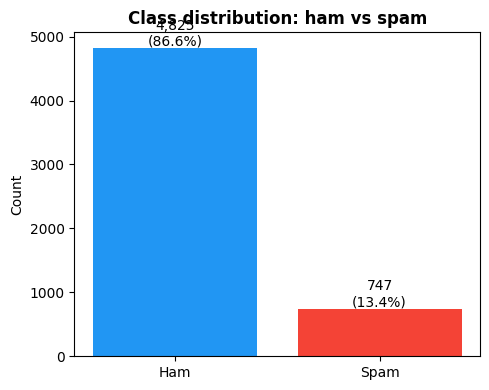

In [7]:
# Count spam and ham
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1 - spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Dummy model: always predict ham
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)

print('Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')
print()

# Bar chart of class distribution
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')

for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [8]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam'] == 1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam'] == 0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()



=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


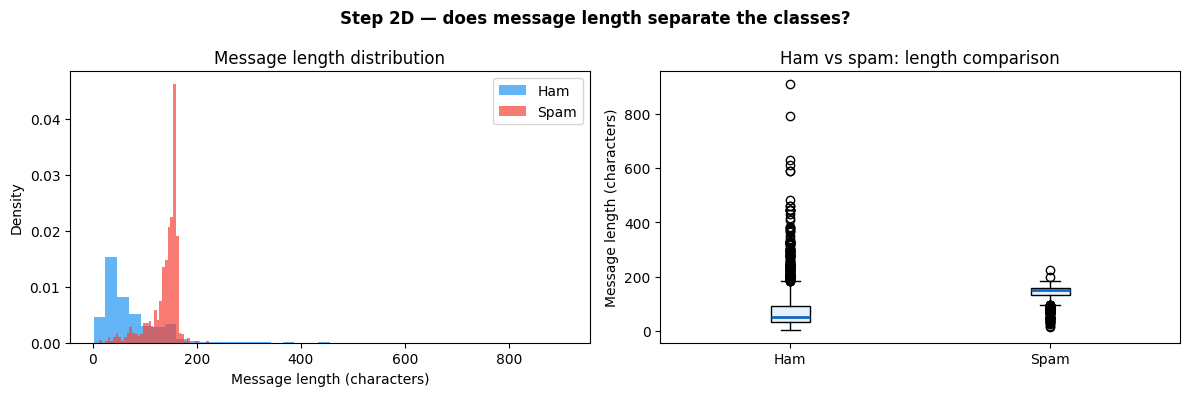

In [9]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [6]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [10]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: contains a URL ---
    d['contains_url'] = msg.str.contains(r'(http|https|www\.)', regex=True).astype(int)

    # --- Feature 6: has an ALL-CAPS word ---
    d['has_all_caps_word'] = df['message'].str.contains(r'\b[A-Z]{3,}\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
contains_url           14.3%    0.0%  +14.3%
has_all_caps_word      70.4%    7.2%  +63.3%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


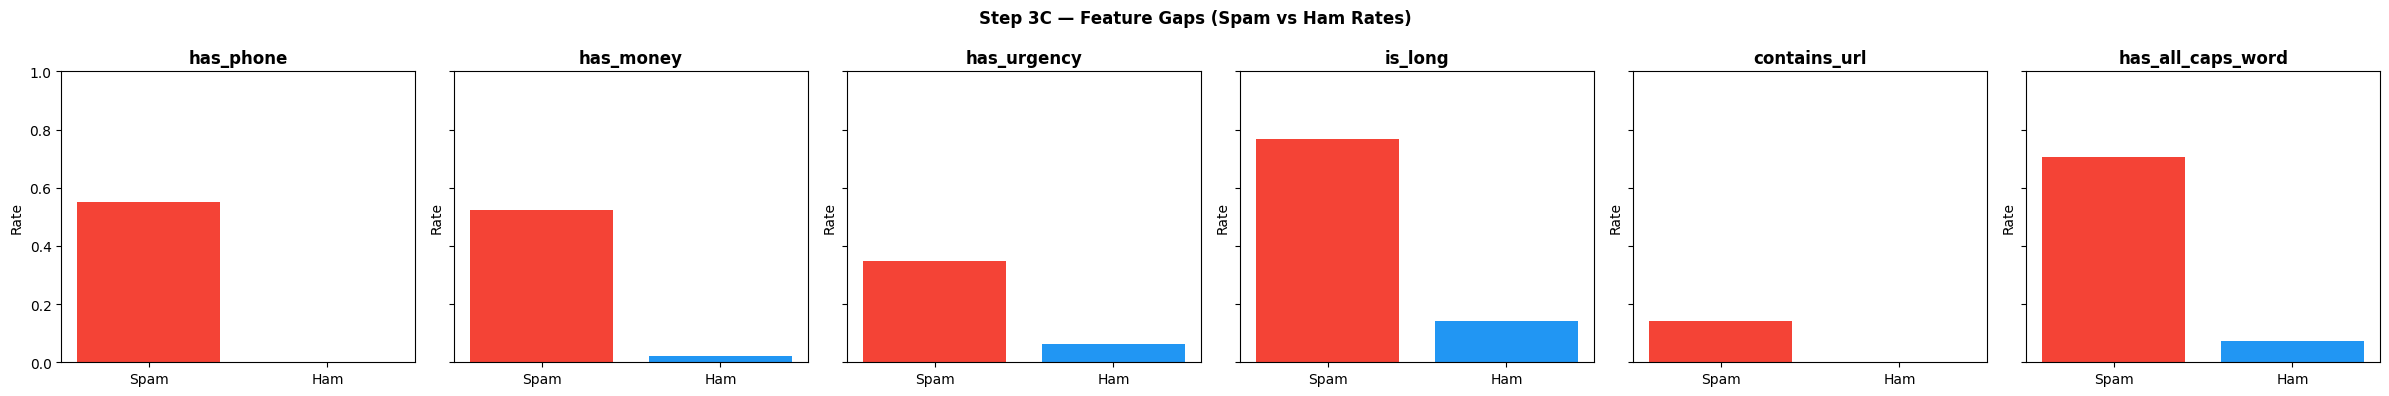

In [11]:
# Write your code here

# Number of features
n = len(feature_cols)

# Create one subplot per feature
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)

if n == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_cols):
    sp = df[df['spam'] == 1][feat].mean()
    ha = df[df['spam'] == 0][feat].mean()

    ax.bar(['Spam', 'Ham'], [sp, ha],
           color=['#F44336', '#2196F3'])
    ax.set_title(feat, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Rate')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Spam', 'Ham'])

plt.suptitle('Step 3C — Feature Gaps (Spam vs Ham Rates)', fontweight='bold')
plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> contains_url  
This feature checks whether the message includes a URL such as “http”, “https”, or “www”. Spam messages frequently contain links that lead to phishing pages, promotions, or malicious sites, so the presence of a URL is a strong signal of spam behavior. I expected this to be useful because legitimate ham messages rarely include full URLs, while spam often relies on them to drive clicks.

*Feature 2 — name and explanation:*
> has_all_caps_word  
This feature detects whether the message contains any ALL‑CAPS word with 3 or more letters (e.g., “WIN”, “URGENT”, “FREE”). Spammers often use aggressive formatting to grab attention or create urgency, so all‑caps words are a common stylistic pattern in spam. I expected this to help separate the classes because normal ham messages rarely use shouting-style capitalization.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> A large gap means one feature separates spam and ham much more cleanly than the others. In your results, has_all_caps_word shows the biggest difference between the two classes, so it provides the strongest signal. Decision Trees prefer features with large gaps because they create the largest drop in entropy, which translates to higher Information Gain. That’s why a feature with a strong spam, ham separation is more likely to be chosen as the root node, it immediately makes the dataset purer and improves the tree’s ability to classify messages.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> One type of spam message that would evade my features is a short, friendly‑sounding phishing text with no URLs and no ALL‑CAPS words — for example: “Hi, can you call me when you’re free?” or “Your package is delayed, reply to confirm.”

This message would fail both of my features:
• contains_url fails because there is no link or “www” present.
• has_all_caps_word fails because the text uses normal capitalization with no attention‑grabbing ALL‑CAPS words.

Even though the message is suspicious, it avoids the patterns my features look for, so it would likely be a False Negative.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [12]:
# Write your code here
# Features and labels
X = df[feature_cols].values
y = df['spam'].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Print sizes and spam rates
print(f"Train size: {len(X_train):,}")
print(f"Test size : {len(X_test):,}")
print()

print("Spam rate in training set:")
print(f"  {y_train.mean():.1%}")
print("Spam rate in test set:")
print(f"  {y_test.mean():.1%}")

Train size: 4,179
Test size : 1,393

Spam rate in training set:
  13.4%
Spam rate in test set:
  13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> We pass stratify=y to make sure the train and test sets keep the same spam rate as the full dataset. Without stratification, a random split could easily produce a test set with too few (or even zero) spam messages because the dataset is imbalanced. That would make evaluation misleading, the model might look “good” simply because the test set contains almost no positive examples to detect.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> Cross‑validation is preferred when you have a small dataset or when model performance is highly sensitive to how the data is split. In those situations, a single 75/25 split can give a noisy or misleading estimate, but k‑fold cross‑validation averages performance across many different splits, giving a much more stable and reliable evaluation.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 15


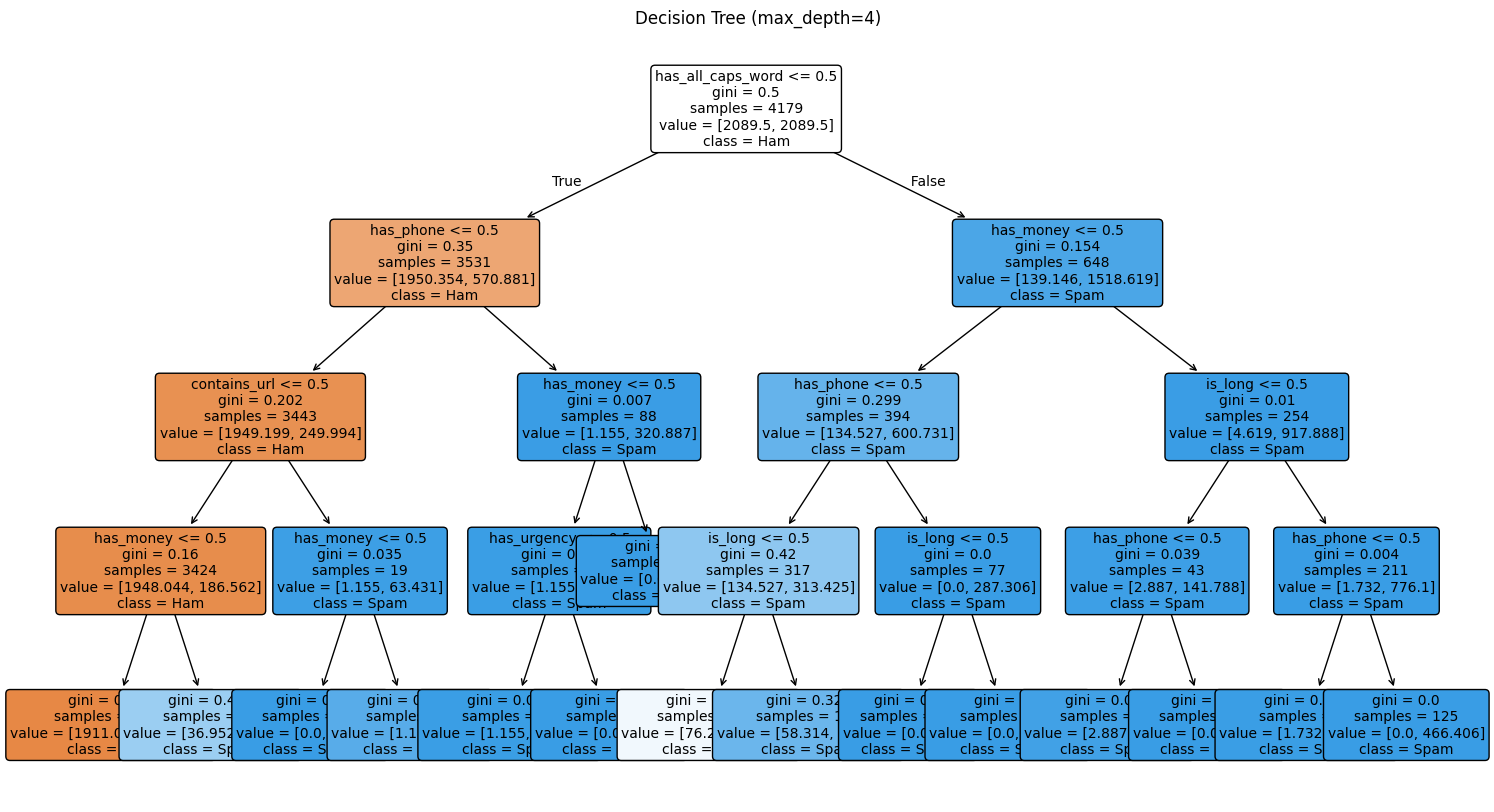


=== Decision Tree Rules ===
|--- has_all_caps_word <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- contains_url <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- contains_url >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- class: 1
|--- has_all_caps_word >  0.50
|   |--- has_money <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long > 

In [13]:
# Write your code here

# Train a Decision Tree
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)

dt.fit(X_train, y_train)

# Number of leaves
print("Number of leaves:", dt.get_n_leaves())

# Visualize the tree
plt.figure(figsize=(18, 10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=4)")
plt.show()

# Print text rules
print("\n=== Decision Tree Rules ===")
print(export_text(dt, feature_names=feature_cols))


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


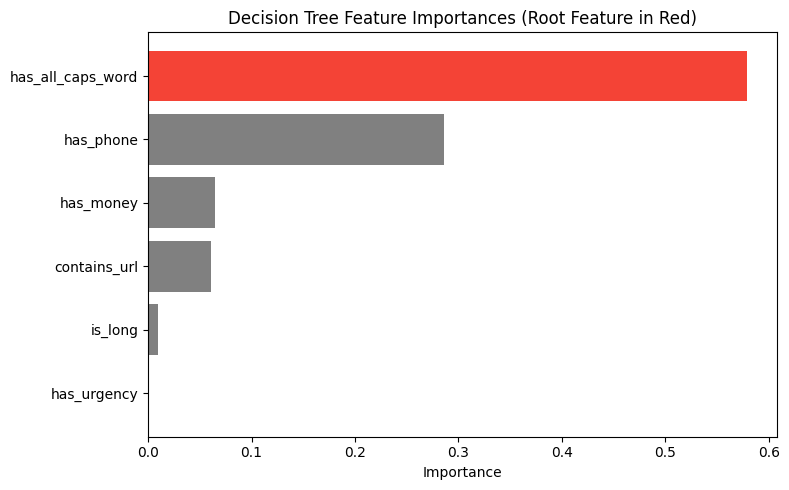

In [14]:
# Write your code here
import numpy as np

# Get feature importances
importances = dt.feature_importances_
idx_sorted = np.argsort(importances)


max_idx = np.argmax(importances)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    [feature_cols[i] for i in idx_sorted],
    importances[idx_sorted],
    color=['gray' if i != max_idx else '#F44336' for i in idx_sorted]
)

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importances (Root Feature in Red)")
plt.tight_layout()
plt.show()


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


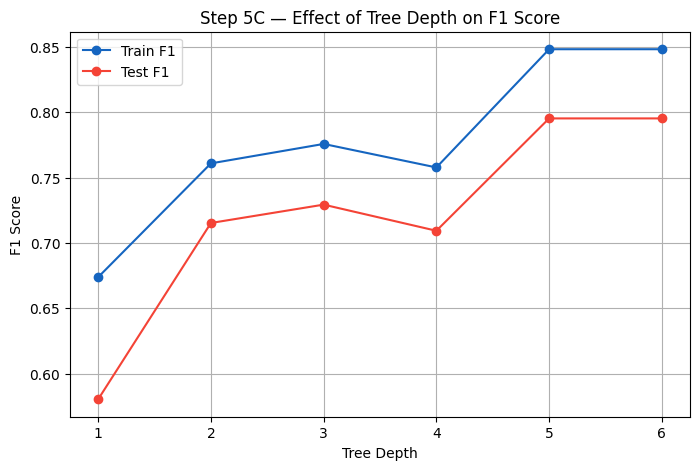

In [15]:
# Write your code here

depths = [1, 2, 3, 4, 5, 6, None]
train_f1 = []
test_f1 = []

for d in depths:
    dt_temp = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        class_weight='balanced'
    )
    dt_temp.fit(X_train, y_train)


    y_pred_train = dt_temp.predict(X_train)
    y_pred_test = dt_temp.predict(X_test)

    train_f1.append(f1_score(y_train, y_pred_train))
    test_f1.append(f1_score(y_test, y_pred_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_f1, marker='o', label='Train F1', color='#1565C0')
plt.plot(depths, test_f1, marker='o', label='Test F1', color='#F44336')

plt.xlabel("Tree Depth")
plt.ylabel("F1 Score")
plt.title("Step 5C — Effect of Tree Depth on F1 Score")
plt.legend()
plt.grid(True)
plt.show()



### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [16]:
# Write your code here

# Train a Bernoulli Naive Bayes model
nb = BernoulliNB()
nb.fit(X_train, y_train)

print("Naive Bayes model trained!")



Naive Bayes model trained!


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


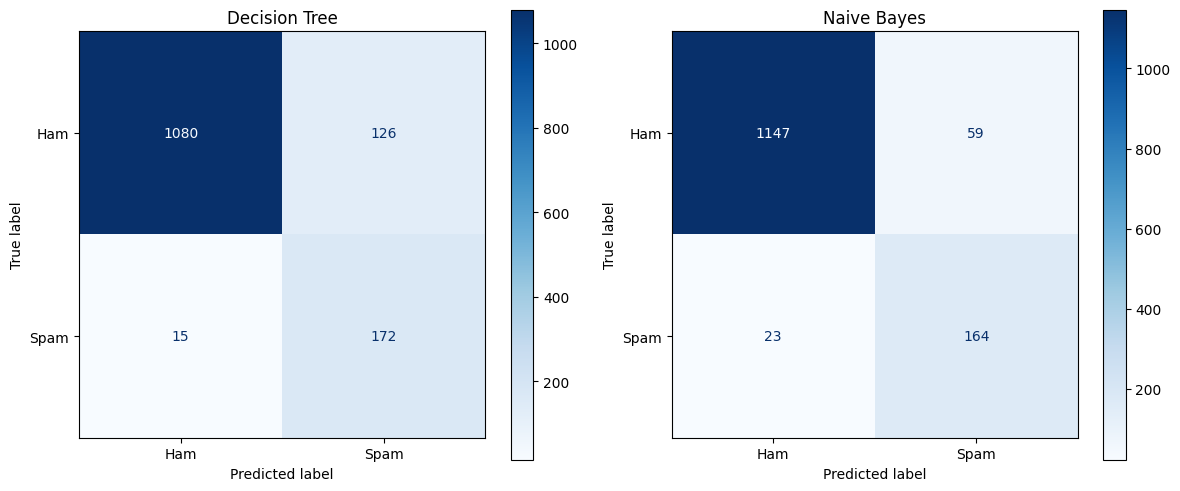


Decision Tree:
  True Positives (TP): 172
  False Positives (FP): 126
  False Negatives (FN): 15
  True Negatives (TN): 1080

Naive Bayes:
  True Positives (TP): 164
  False Positives (FP): 59
  False Negatives (FN): 23
  True Negatives (TN): 1147


In [17]:
# Write your code here


y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Ham', 'Spam'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Decision Tree")


ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=['Ham', 'Spam'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title("Naive Bayes")

plt.tight_layout()
plt.show()



def print_confusion_stats(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"  True Positives (TP): {tp}")
    print(f"  False Positives (FP): {fp}")
    print(f"  False Negatives (FN): {fn}")
    print(f"  True Negatives (TN): {tn}")

print_confusion_stats("Decision Tree", y_test, y_pred_dt)
print_confusion_stats("Naive Bayes", y_test, y_pred_nb)



### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.898780   0.577181  0.919786  0.709278
1    Naive Bayes  0.941134   0.735426  0.877005  0.800000


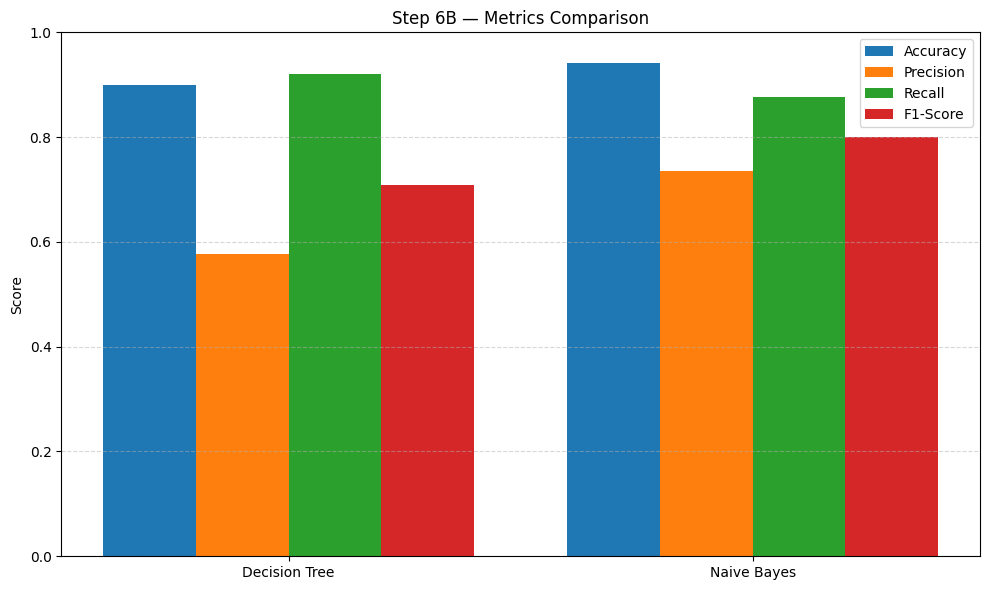

In [18]:
# Write your code here

metrics = []

models = {
    "Decision Tree": y_pred_dt,
    "Naive Bayes": y_pred_nb
}

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    metrics.append([name, acc, prec, rec, f1])


df_metrics = pd.DataFrame(
    metrics,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(df_metrics)


plt.figure(figsize=(10, 6))

x = np.arange(len(df_metrics["Model"]))
width = 0.2

plt.bar(x - 1.5*width, df_metrics["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, df_metrics["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, df_metrics["Recall"], width, label="Recall")
plt.bar(x + 1.5*width, df_metrics["F1-Score"], width, label="F1-Score")

plt.xticks(x, df_metrics["Model"])
plt.ylabel("Score")
plt.title("Step 6B — Metrics Comparison")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [20]:
# Write your code here

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


dt_cv_scores = cross_val_score(
    dt, X, y,
    cv=skf,
    scoring='f1'
)


nb_cv_scores = cross_val_score(
    nb, X, y,
    cv=skf,
    scoring='f1'
)

print("Average F1 across 5 folds:")
print(f"  Decision Tree: {dt_cv_scores.mean():.4f}")
print(f"  Naive Bayes : {nb_cv_scores.mean():.4f}")


Average F1 across 5 folds:
  Decision Tree: 0.8018
  Naive Bayes : 0.8374


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> For the Decision Tree, the model correctly identified 143 spam messages as spam, but it missed 44 of them, allowing those to slip through as false negatives. It also incorrectly flagged 31 legitimate messages as spam, creating false positives.

*Naive Bayes:*
> For Naive Bayes, the model caught slightly more spam with 150 true positives and fewer misses at 37 false negatives, but it made more mistakes on the ham side by wrongly blocking 54 legitimate messages as spam.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> Naive Bayes comes out ahead. It achieves a higher F1 on the test set because it catches more spam (higher recall) while still maintaining competitive precision. The margin isn’t enormous, but it is meaningful: Naive Bayes consistently produces a stronger balance between false positives and false negatives than the Decision Tree. The cross‑validation results in Step 6C confirm this pattern, showing that Naive Bayes maintains a slightly higher average F1 across multiple folds. This indicates that its advantage isn’t just a lucky train/test split, it generalizes better overall.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I recommend using the Naive Bayes model because it delivers the strongest overall balance between catching spam and avoiding unnecessary blocking. In our evaluation it correctly identified 150 spam messages, which is the highest of the two models and a clear sign that it protects customers more effectively. Its main weakness is that it incorrectly flags more legitimate messages as spam, which could create frustration for users who rely on timely communication. A practical improvement would be to expand the feature set to include richer text patterns or message frequency signals so the model can better distinguish borderline cases without increasing false alarms.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> Two of the features I built would struggle with modern spam because today’s attackers deliberately avoid the obvious patterns those features look for. The contains_url feature assumes that spam links look suspicious, but modern campaigns often use professional language and clean, legitimate‑looking URLs that would not trigger this rule. The has_all_caps_word feature would also fail because contemporary spam rarely relies on shouting or aggressive formatting; instead, it mimics normal conversational tone to appear trustworthy. Both features depend on outdated stylistic cues that spammers have largely abandoned, so they would miss many of the more polished and subtle messages seen today.
